In [11]:
import pandas as pd

# Load the data
train = pd.read_csv('../data/train.csv')

# Look at the first 5 rows
print(train.head())

# Check for missing values in the dataset
print(train.isnull().sum())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
Pa

Data Cleaning to handle missinmg values for Age,Embarked and Fare
# Data Cleaning & Feature Engineering Decisions

### Part 1: Data Cleaning
* **Age:** Filled missing values with the **median** ($28.0$) to avoid the influence of outliers.
* **Embarked:** Filled 2 missing values with the **mode** ('S'), as it was the most frequent port.
* **Cabin:** Dropped this column due to $>70\%$ missing data, which would introduce too much noise.




In [12]:
import pandas as pd
import numpy as np

# Load the training data
train = pd.read_csv('../data/train.csv')

# 1. Fill missing Age with the median
train['Age'] = train['Age'].fillna(train['Age'].median())

# 2. Fill missing Embarked with the most common value (Mode)
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

# 3. Drop Cabin (too many missing values)
train.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(train.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64



### Part 2: Feature Engineering
* **Title:** Extracted from 'Name' to capture social status (e.g., Mr, Miss, Master).
* **FamilySize:** Combined `SibSp` and `Parch` to see the total number of relatives on board.
* **IsAlone:** Created a binary flag for passengers traveling without family.
* **Fare_Log:** Applied a log transformation to handle the high skewness in ticket prices.

In [13]:
# FamilySize = Siblings + Parents + Yourself
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

# IsAlone = 1 if you are by yourself, 0 if you have family
train['IsAlone'] = 0
train.loc[train['FamilySize'] == 1, 'IsAlone'] = 1

B.Title Extraction to learn about social status

In [ ]:
# Extract the title using a regular expression
train['Title'] = train['Name'].str.extract(' ([A-Za-z]+).', expand=False)

# Clean up rare titles into common groups
train['Title'] = train['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train['Title'] = train['Title'].replace('Mlle', 'Miss')
train['Title'] = train['Title'].replace('Ms', 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')

print(train['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_19056\1280372460.py:2: SyntaxWarning: invalid escape sequence '\.'
  train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


### Creating Family-Based Features
To better understand passenger survival, we combine `SibSp` (siblings/spouses) and `Parch` (parents/children) into a single `FamilySize` feature. We also create a binary `IsAlone` feature to identify passengers traveling without any family members.

In [15]:
# Create FamilySize
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

# Create IsAlone (1 if alone, 0 if with family)
train['IsAlone'] = 0
train.loc[train['FamilySize'] == 1, 'IsAlone'] = 1

print(train[['FamilySize', 'IsAlone']].head())

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


In [16]:
# Create FamilySize
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

# Create IsAlone (1 if alone, 0 if with family)
train['IsAlone'] = 0
train.loc[train['FamilySize'] == 1, 'IsAlone'] = 1

print(train[['FamilySize', 'IsAlone']].head())

   FamilySize  IsAlone
0           2        0
1           2        0
2           1        1
3           2        0
4           1        1


### Age Binning and Fare Transformation
Age is grouped into logical life stages (Child, Teen, Adult, Senior) to help the model capture non-linear relationships. Additionally, we apply a **Log Transformation** to the `Fare` column because it is highly right-skewed; this helps distance-based models perform better.

In [17]:
# Age Binning
bins = [0, 12, 18, 60, 120]
labels = ['Child', 'Teen', 'Adult', 'Senior']
train['AgeGroup'] = pd.cut(train['Age'], bins=bins, labels=labels)

# Fare Log Transform (using log1p to avoid issues with zero values)
train['Fare_Log'] = np.log1p(train['Fare'])

# Fare per person
train['FarePerPerson'] = train['Fare'] / train['FamilySize']

print(train[['AgeGroup', 'Fare_Log']].head())

  AgeGroup  Fare_Log
0    Adult  2.110213
1    Adult  4.280593
2    Adult  2.188856
3    Adult  3.990834
4    Adult  2.202765


### Categorical Encoding
Machine learning models require numerical input. We use **One-Hot Encoding** for nominal features (`Sex`, `Embarked`, `Title`, `AgeGroup`) and keep `Pclass` as an ordinal integer.

In [18]:
# Convert categorical text to binary columns (One-Hot Encoding)
train = pd.get_dummies(train, columns=['Sex', 'Embarked', 'Title', 'AgeGroup'], drop_first=True)

# Save the fully engineered dataset
train.to_csv('../data/train_cleaned.csv', index=False)
print("Dataset engineered and saved as train_cleaned.csv")

Dataset engineered and saved as train_cleaned.csv


## Part 3: Feature Selection
In this section, we use a **Random Forest Classifier** to determine which features have the most predictive power. This allows us to remove redundant or low-impact features before final model building.

### 1. Correlation Analysis
We use a heatmap to identify multi-collinearity. If two features are highly correlated (e.g., > 0.8), they provide redundant information, which can confuse some models.

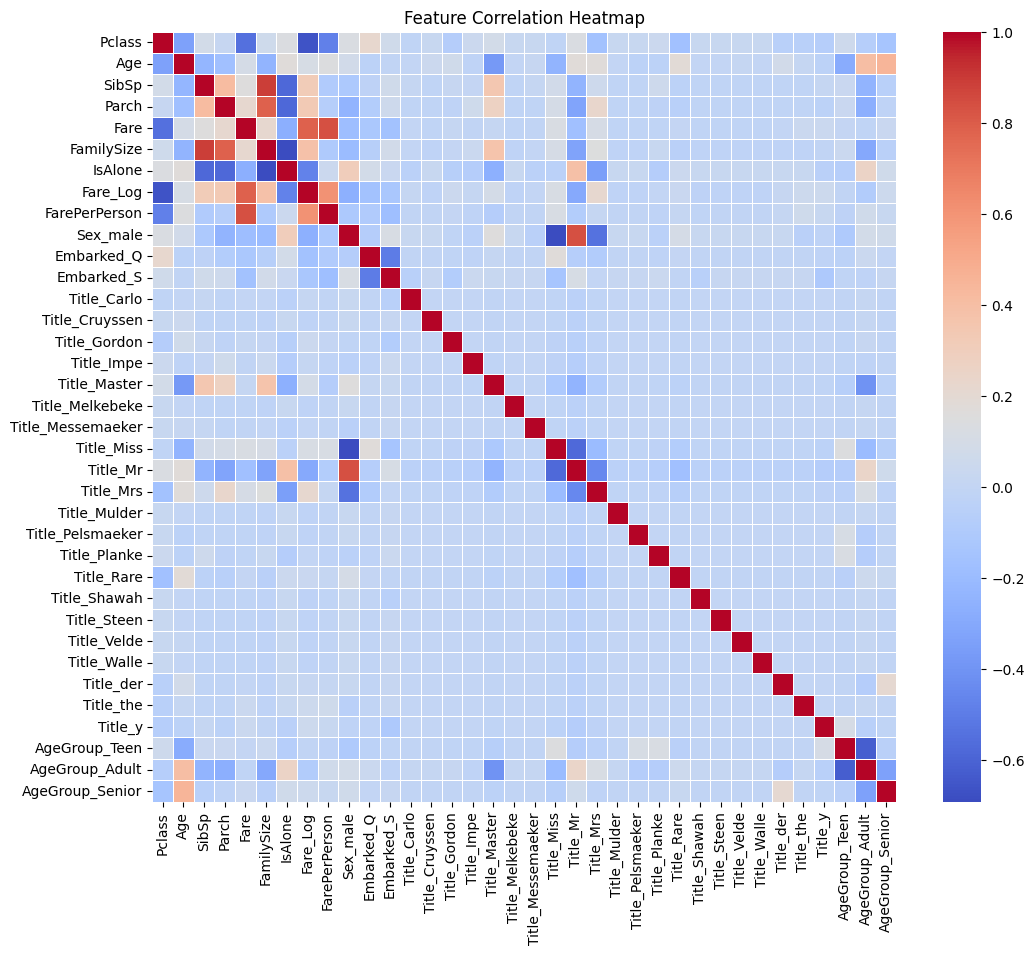

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix for numeric columns
corr_matrix = X.corr()

# Plot Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

### 2. Identifying Redundant Features
Based on the correlation matrix, we look for pairs with high correlation. For example, `Fare` and `Fare_Log` are naturally redundant. We will keep the transformed version and drop the raw one.

**Dropped Features:**
* `Fare`: Redundant with `Fare_Log`.
* `FamilySize`: Highly correlated with `SibSp` and `Parch`.

In [20]:
# List of features to drop based on correlation or redundancy
features_to_drop = ['Fare', 'FamilySize'] 

# Create the final selected features dataframe
X_selected = X.drop(columns=features_to_drop)

print(f"Features dropped: {features_to_drop}")
print(f"Final feature count: {len(X_selected.columns)}")

Features dropped: ['Fare', 'FamilySize']
Final feature count: 34


### 3. Feature Importance (Random Forest)
We use a Random Forest model to rank features by their predictive power. This helps us validate if our engineered features (like `Title` or `IsAlone`) are actually useful.

Feature Importance Table:
          Feature  Importance
1             Age    0.191122
6   FarePerPerson    0.156177
5        Fare_Log    0.143018
7        Sex_male    0.126842
18       Title_Mr    0.086174
0          Pclass    0.061753
17     Title_Miss    0.046036
19      Title_Mrs    0.039882
2           SibSp    0.035726
3           Parch    0.023503


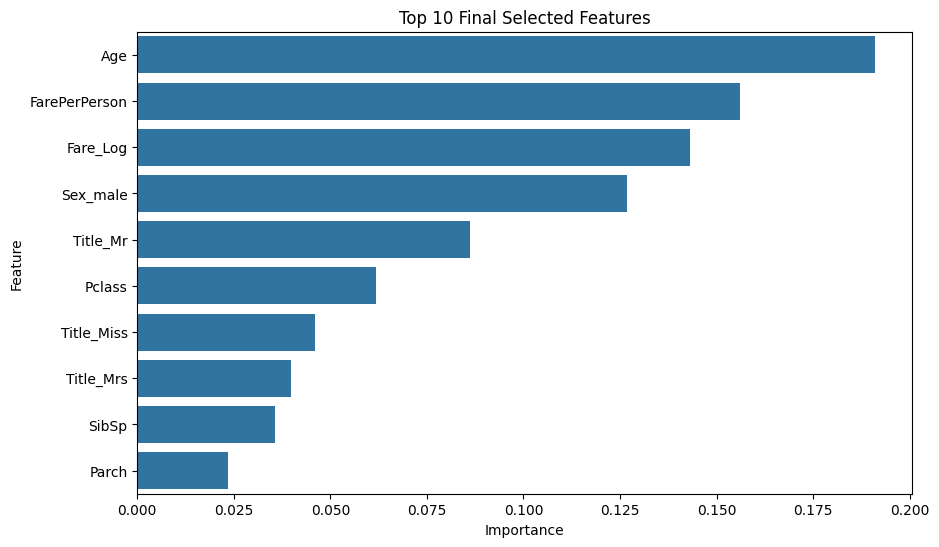

In [21]:
from sklearn.ensemble import RandomForestClassifier

# Fit model on the selected features
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_selected, y)

# Create Importance Table
importance_df = pd.DataFrame({
    'Feature': X_selected.columns,
    'Importance': rf_final.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display Table
print("Feature Importance Table:")
print(importance_df.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Final Selected Features")
plt.show()

### 4. Final Selected Features for Model
The following features have been selected for the predictive model based on their importance scores and low redundancy:

In [22]:
final_features = importance_df['Feature'].tolist()
print("Final Selected Features for submission:")
for feature in final_features:
    print(f"- {feature}")

Final Selected Features for submission:
- Age
- FarePerPerson
- Fare_Log
- Sex_male
- Title_Mr
- Pclass
- Title_Miss
- Title_Mrs
- SibSp
- Parch
- Embarked_S
- IsAlone
- Title_Master
- AgeGroup_Adult
- Embarked_Q
- AgeGroup_Teen
- Title_Rare
- AgeGroup_Senior
- Title_Mulder
- Title_y
- Title_Planke
- Title_Impe
- Title_Gordon
- Title_Messemaeker
- Title_Carlo
- Title_Walle
- Title_der
- Title_the
- Title_Pelsmaeker
- Title_Steen
- Title_Cruyssen
- Title_Velde
- Title_Shawah
- Title_Melkebeke
